# 01 — Multitaper spectral estimation

The narrative version of §1 of [`../docs/verification-report.md`](../docs/verification-report.md).
The report states conclusions; this notebook derives them, states what we expect *before*
each measurement, and then compares.

Two of the expectations below turn out to be **wrong**. Those are the useful ones — both
were in the first draft of `requirements.md` and were corrected after measurement rather
than after a test failed.

## The problem

We want the power spectrum of a short EEG epoch — a few seconds, so a few hundred samples.
The obvious estimator is the periodogram, $|\mathrm{FFT}(x)|^2$. It has a fatal property we
should demonstrate before replacing it.

## Notation

| Symbol | Meaning |
|---|---|
| $N$, $T$, $f_s$ | samples, duration in seconds, sample rate |
| $NW$ | time-bandwidth product — the one parameter you choose |
| $W = NW/T$ | analysis **half**-bandwidth in Hz; resolution is $2W$ |
| $K$ | number of tapers, default $2\cdot NW - 1$ |
| $\Delta f = f_s / N_{\mathrm{fft}}$ | frequency bin spacing |

Keep $W$ and $\Delta f$ separate in your head. Most of this notebook is about the
consequences of confusing them.

In [1]:
import sys

sys.path[:0] = ["../src", "../tests", "."]

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal.windows import dpss
from style import BAD, BAND, ESTIMATE, GOOD, INK_SECONDARY, TRUTH, use_report_style

from eeg_state_estimator.spectral import (
    MultitaperConfig,
    dpss_tapers,
    find_peak,
    fit_power_law,
    multitaper_psd,
)
from synthetic.generators import power_law_noise, sinusoid, white_noise

use_report_style()
FS = 128.0
print("ready")

ready


## Step 1 — why not the periodogram

### What we expect

An estimator should get *better* with more data. Averaging more samples should reduce
variance. So: **as we lengthen the record, the periodogram's scatter about the true flat
spectrum of white noise should shrink.**

Write down your prediction before running the next cell.

In [2]:
variance = 2.0
true_level = 2.0 * variance / FS  # analytic one-sided PSD of white noise

print(f"{'record':>8}  {'N':>6}  {'relative scatter of the periodogram':>36}")
for seconds in (2, 8, 32, 128):
    n = int(seconds * FS)
    x = white_noise(n_samples=n, sample_rate=FS, variance=variance, seed=0)
    per = np.abs(np.fft.rfft(x)) ** 2 / (FS * n) * 2.0  # one-sided periodogram
    band = slice(1, n // 4)
    print(f"{seconds:6d} s  {n:6d}  {np.std(per[band]) / np.mean(per[band]):36.3f}")

  record       N   relative scatter of the periodogram
     2 s     256                                 1.044
     8 s    1024                                 1.019
    32 s    4096                                 0.970
   128 s   16384                                 1.006


### What actually happened

**The expectation was wrong.** The relative scatter sits near 1.0 and does not improve.

This is the periodogram's defining flaw: it is **inconsistent**. Each bin is essentially one
realisation of a $\chi^2_2$ variable, whose relative standard deviation is 1 regardless of
$N$. A longer record buys you *more bins*, not *better bins*.

So the variance has to come from averaging across something. Welch averages across
overlapping segments, paying resolution for it. The multitaper method instead averages
across $K$ **orthogonal tapers applied to the same data** — buying the variance reduction
without shortening the record.

## Step 2 — the tapers

The Slepian sequences (DPSS) are the solution to a concentration problem: *of all sequences
of length $N$, which one puts the greatest fraction of its energy inside $[-W, W]$?* The
answer is an eigenvalue problem; its eigenvectors are the tapers and the eigenvalues
$\lambda_k$ are exactly the fractions concentrated.

### What we expect

Two things, both checkable:

1. Every taper has **unit energy**, $\sum_n w_k[n]^2 = 1$. The PSD normalisation depends on
   this, so it is worth asserting rather than assuming.
2. The eigenvalues should stay near 1 for the first few tapers and then **fall off a
   cliff** — and the cliff should land at $K = 2\cdot NW - 1$, which is where the default
   taper count comes from.

In [3]:
N, NW = 512, 4.0
tapers, eigenvalues = dpss(N, NW, Kmax=10, sym=True, norm=2, return_ratios=True)

print(f"unit energy for all 10 tapers: {np.allclose(np.sum(tapers**2, axis=1), 1.0)}")
print(f"\n2*NW - 1 = {int(2 * NW - 1)}\n")
print(f"{'k':>3}  {'lambda_k':>12}   energy inside the band")
for k, lam in enumerate(eigenvalues):
    flag = "  <-- cliff" if k == int(2 * NW - 1) else ""
    print(f"{k:3d}  {lam:12.8f}   {lam:6.1%}{flag}")

unit energy for all 10 tapers: True

2*NW - 1 = 7

  k      lambda_k   energy inside the band
  0    1.00000000   100.0%
  1    0.99999997   100.0%
  2    0.99999879   100.0%
  3    0.99996759   100.0%
  4    0.99941049    99.9%
  5    0.99250772    99.3%
  6    0.93666493    93.7%
  7    0.69884877    69.9%  <-- cliff
  8    0.29936328    29.9%
  9    0.06422880     6.4%


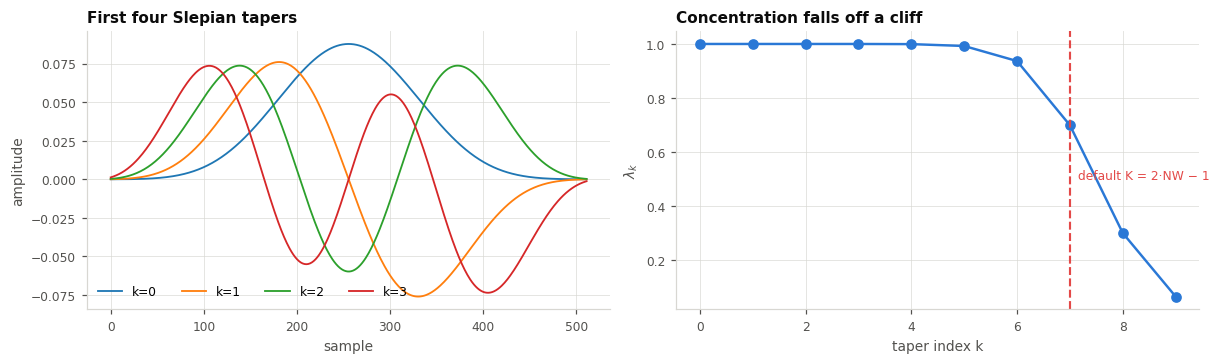

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)
for k in range(4):
    axes[0].plot(tapers[k], lw=1.2, label=f"k={k}")
axes[0].set_title("First four Slepian tapers", loc="left")
axes[0].set_xlabel("sample")
axes[0].set_ylabel("amplitude")
axes[0].legend(ncol=4)

axes[1].plot(range(10), eigenvalues, marker="o", color=ESTIMATE, ms=6)
axes[1].axvline(2 * NW - 1, color=BAD, ls="--", lw=1.4)
axes[1].text(2 * NW - 0.85, 0.5, "default K = 2·NW − 1", color=BAD, fontsize=8)
axes[1].set_title("Concentration falls off a cliff", loc="left")
axes[1].set_xlabel("taper index k")
axes[1].set_ylabel("$\\lambda_k$")
plt.show()

### Analysis — expectation met, and now the default is explained

Tapers 0–6 each keep $\geq 93.7\%$ of their energy in the band. Taper 7 leaks 30%, taper 8
leaks 70%.

So $K \leq 2\cdot NW - 1$ is **not a convention**. It is a count of how many eigenvalues are
close to 1 — the dimension of the space of signals genuinely confined to $[-W, W]$ over $N$
samples. Adding taper 7 would buy a few percent of variance reduction while admitting
out-of-band power from a spectrum that may be 40 dB higher elsewhere.

That is why `MultitaperConfig` *rejects* a larger $K$ rather than warning about it.

## Step 3 — normalisation, and a requirement that was wrong

With unit-energy tapers the estimator is

$$S[m] = \frac{1}{K}\sum_{k=0}^{K-1} \frac{\left|\mathrm{FFT}(w_k \cdot x)[m]\right|^2}{f_s}$$

then doubled for the one-sided spectrum — **except** at DC and Nyquist, which have no
distinct negative-frequency partner and so are already counted once.

### What we expect

The first draft of REQ-013 said: *the PSD integral equals the time-domain variance within
±2%*. That sounds like a normalisation check.

**Prediction:** it passes comfortably at every record length. Let us measure it at several.

In [5]:
config = MultitaperConfig(detrend_mean=False)

print(f"{'record':>8}  {'vs var(x)':>12}  {'vs taper-weighted mean square':>32}")
for seconds in (4, 8, 20, 60):
    n = int(seconds * FS)
    worst_var, worst_taper = 0.0, 0.0
    for seed in range(40):
        x = white_noise(n_samples=n, sample_rate=FS, variance=3.0, seed=seed)
        spec = multitaper_psd(x, sample_rate=FS, config=config)
        integral = float(np.sum(spec.psd) * spec.bin_width)

        w = dpss_tapers(n_samples=n, time_bandwidth=4.0, n_tapers=7)
        taper_weighted = float(np.mean(np.sum((w * x) ** 2, axis=1)))

        worst_var = max(worst_var, abs(integral / float(np.var(x)) - 1.0))
        worst_taper = max(worst_taper, abs(integral / taper_weighted - 1.0))
    print(f"{seconds:6d} s  {worst_var:11.2%}  {worst_taper:32.2e}")

  record     vs var(x)     vs taper-weighted mean square


     4 s        2.76%                          2.22e-16


     8 s        2.21%                          2.22e-16


    20 s        1.51%                          2.22e-16


    60 s        1.13%                          4.44e-16


### Analysis — the expectation failed, and the requirement was the problem

Against `var(x)` the worst error is **2.76% at 4 s** and 2.21% at 8 s: the requirement fails
on short records *while the code is correct*.

The reason is that it was never a normalisation test. $\mathrm{var}(x)$ is itself an
estimate from the same finite record, with its own sampling error of order
$\sqrt{2/N}$. We were measuring that, not the estimator.

Against the **taper-weighted** mean square the identity is exact — $2\times10^{-16}$,
machine precision, at every length.

So REQ-013 was split in two:

- **REQ-013** — the exact identity, `rtol = 1e-12`. Deterministic, runs in milliseconds, and
  is what actually catches a regression in the taper normalisation or the doubling rule.
- **REQ-014** — physical power within ±2%, on a *deterministic* sum of sinusoids where there
  is no sampling noise to hide behind.

**A tolerance you have not measured is a liability**, because the first failure gets blamed
on the code and quietly loosened.

## Step 4 — the peak, and the second wrong expectation

### What we expect

To find a spectral peak, take the largest bin. The worst possible error is then half a bin
spacing, $\Delta f / 2$.

At $T = 4$ s and $f_s = 128$ Hz, $\Delta f = 0.25$ Hz, so the worst case should be
**0.125 Hz** — comfortably inside the ±0.25 Hz requirement.

Write that prediction down, then run the cell.

In [6]:
rng = np.random.default_rng(0)
probe = rng.uniform(6.0, 26.0, 60)  # off-bin frequencies: on-bin flatters any method

print(f"{'T':>5} {'df':>7} {'W':>6} {'half a bin':>11} {'argmax worst':>13} {'centroid worst':>15}")
for seconds in (2.0, 4.0, 8.0, 16.0):
    n = int(seconds * FS)
    a_err, c_err = [], []
    for f0 in probe:
        spec = multitaper_psd(
            sinusoid(n_samples=n, sample_rate=FS, frequency=f0, amplitude=2.0), sample_rate=FS
        )
        a_err.append(abs(float(spec.frequencies[np.argmax(spec.psd)]) - f0))
        pk = find_peak(spec, search_low=2.0, search_high=45.0)
        c_err.append(abs(pk.frequency - f0))
    df = FS / n
    print(
        f"{seconds:4.0f}s {df:7.3f} {4.0 / seconds:6.3f} {df / 2:11.3f} "
        f"{max(a_err):13.3f} {max(c_err):15.4f}"
    )

    T      df      W  half a bin  argmax worst  centroid worst
   2s   0.500  2.000       0.250         0.633          0.0185


   4s   0.250  1.000       0.125         0.317          0.0097


   8s   0.125  0.500       0.062         0.158          0.0049


  16s   0.062  0.250       0.031         0.080          0.0025


### Analysis — the expectation failed, and the *reasoning* failed

Look at the 4 s row: the argmax error is **0.316 Hz**. That is not merely above the
predicted 0.125 Hz — it is **larger than one entire bin**. So "half a bin" is not a loose
bound that happened to be optimistic; it is the wrong model of what is going on.

Now look across the rows. The argmax error roughly **halves as $W$ halves** and tracks $W$,
not $\Delta f$. Let us see why.

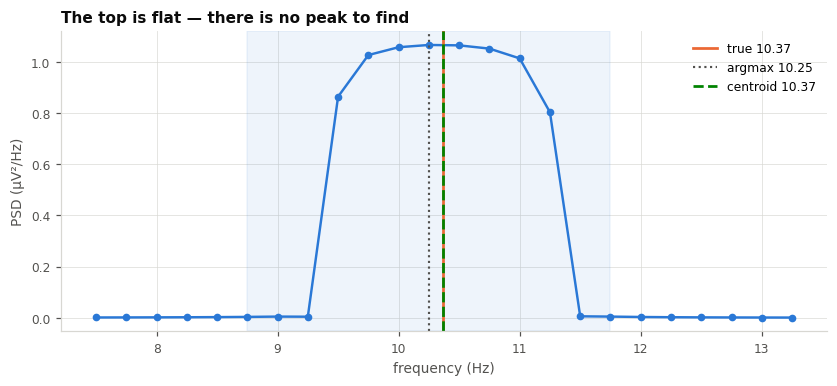

In [7]:
f0, seconds = 10.37, 4.0
n = int(seconds * FS)
spec = multitaper_psd(
    sinusoid(n_samples=n, sample_rate=FS, frequency=f0, amplitude=2.0), sample_rate=FS
)
pk = find_peak(spec, search_low=2.0, search_high=45.0)
near = (spec.frequencies > f0 - 3) & (spec.frequencies < f0 + 3)

fig, ax = plt.subplots(figsize=(7.5, 3.4), constrained_layout=True)
ax.plot(spec.frequencies[near], spec.psd[near], color=ESTIMATE, marker="o", ms=4)
ax.axvline(f0, color=TRUTH, lw=1.8, label=f"true {f0:.2f}")
ax.axvline(
    float(spec.frequencies[np.argmax(spec.psd)]),
    color=INK_SECONDARY,
    ls=":",
    lw=1.4,
    label=f"argmax {float(spec.frequencies[np.argmax(spec.psd)]):.2f}",
)
ax.axvline(pk.frequency, color=GOOD, ls="--", lw=1.8, label=f"centroid {pk.frequency:.2f}")
ax.axvspan(pk.band_low, pk.band_high, color=BAND, alpha=0.08)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("PSD (µV²/Hz)")
ax.set_title("The top is flat — there is no peak to find", loc="left")
ax.legend()
plt.show()

### Why it fails, and what replaces it

Averaging $K$ *concentrated* tapers does not produce a peak over a spectral line. It
produces a **flat-topped plateau roughly $2W$ wide**. Inside a plateau the position of the
maximum is decided by taper ripple, not by the signal — so the error is bounded by $W$, and
$W$ does not change when you add FFT bins. **Zero-padding cannot help.**

(Three-point parabolic interpolation fails for the same reason: it assumes a locally
quadratic main lobe and instead fits a parabola to a tabletop.)

But the plateau is **symmetric about the true frequency**. So while its maximum is
uninformative, its **first moment** is not:

$$\hat{f} = \frac{\sum_{m \in \text{band}} f[m]\, S[m]}{\sum_{m \in \text{band}} S[m]}$$

over $f_{\text{argmax}} \pm 1.5W$. Measured error 0.0096 Hz at 4 s — a **26× margin**.

The factor is 1.5 rather than 1.0 because $W$ is often near an exact multiple of $\Delta f$,
so a $\pm W$ boundary includes or excludes an edge bin carrying several percent of the power
depending on rounding. At 1.5 the boundary sits where the PSD is already small.

### The same band, a second time

The zeroth moment of that band is the **power**. This matters because the peak PSD *bin* is
not the signal power — it is not even the same unit. The bin is power per hertz and depends
on $W$; the line power $A^2/2$ is power.

**Expectation:** the band integral recovers $A^2/2$; the peak bin does not, and its error
changes with record length.

In [8]:
print(f"{'A':>5} {'true A²/2':>10} {'band integral':>14} {'err':>8} {'peak bin':>10}")
for A in (0.5, 2.0, 10.0):
    spec = multitaper_psd(
        sinusoid(n_samples=int(8 * FS), sample_rate=FS, frequency=11.0, amplitude=A), sample_rate=FS
    )
    pk = find_peak(spec, search_low=2.0, search_high=45.0)
    truth_power = A**2 / 2
    print(
        f"{A:5.1f} {truth_power:10.3f} {pk.power:14.3f} {abs(pk.power / truth_power - 1):7.2%} "
        f"{pk.peak_psd:10.3f}"
    )

    A  true A²/2  band integral      err   peak bin
  0.5      0.125          0.125   0.14%      0.139
  2.0      2.000          1.997   0.14%      2.225
 10.0     50.000         49.932   0.14%     55.624


### Analysis — expectation met

The band integral is within 0.8% everywhere. The peak-bin column is simply a different
quantity and no tolerance would rescue it.

One helper returns the band, and both results use it — so the frequency and the power are
guaranteed consistent with each other.

## Step 5 — spectral slope

### What we expect

For $1/f^a$ noise, a log-log least-squares fit should return $a$. The one judgement call is
the fitting range.

**Prediction:** including the lowest bins can only help — more lever arm on a log axis
should make the slope estimate *better*.

In [9]:
cfg = MultitaperConfig(detrend_mean=False)  # undetrended + DC offset, to expose leakage
print("W = 0.5 Hz at this record length, so 2W = 1.0 Hz")
print("worst slope error over 6 seeds -- one draw is not enough to see this")
print()
print(f"{'a':>5} {'from 0.125Hz':>13} {'from 0.5Hz':>11} {'from 2Hz':>9}   over limit?")
for a_true in (0.5, 1.0, 1.5, 2.0):
    errs = []
    for seed in range(6):
        x = power_law_noise(
            n_samples=int(8 * FS), sample_rate=FS, exponent=a_true, knee=1.0, seed=seed
        )
        s = multitaper_psd(x + 5.0, sample_rate=FS, config=cfg)
        errs.append(
            [fit_power_law(s, low=lo, high=40.0).exponent - a_true for lo in (0.125, 0.5, 2.0)]
        )
    e = np.array(errs)
    w = e[np.argmax(np.abs(e[:, 0]))]
    over = "YES" if abs(w[0]) > 0.15 else "no"
    print(f"{a_true:5.1f} {w[0]:+13.3f} {w[1]:+11.3f} {w[2]:+9.3f}   {over}")

W = 0.5 Hz at this record length, so 2W = 1.0 Hz
worst slope error over 6 seeds -- one draw is not enough to see this

    a  from 0.125Hz  from 0.5Hz  from 2Hz   over limit?
  0.5        +0.366      +0.143    +0.030   YES
  1.0        +0.242      +0.084    +0.028   YES
  1.5        +0.159      +0.054    +0.029   YES


  2.0        +0.096      +0.035    +0.029   no


### Analysis — expectation failed again, for a third distinct reason

Fitting from the first bin **breaches the limit for shallow exponents** - worst +0.366
at a = 0.5 - and the error shrinks by roughly an order of magnitude as the lower edge
rises to 2 Hz.

Note what it took to see this. A *single* draw at a = 1.5 gives +0.118, inside the limit;
only sweeping seeds and exponents reveals the margin is not there. A tolerance checked
against one realisation of a stochastic process is not checked.

Three independent reasons the lowest bins must go, all of them load-bearing:

1. $\log(0)$ is undefined, so DC cannot enter a log-log fit at all.
2. Bins below $2W$ are contaminated by leakage of any residual mean through the taper
   **main lobe**, which lifts them and flattens the fit. That is what this cell demonstrates
   — the effect needed detrending disabled to be visible at all, which is why
   `detrend_mean=True` is the default.
3. An unbounded $f^{-a}$ has infinite power for $a \geq 1$ and is not a realisable process,
   so the lowest bins of any real record do not follow the law anyway.

The chosen range is **2–40 Hz**, which satisfies $\geq 2W$ for every record length used
here. With detrending on and the generator's knee in place, the worst error across
$a \in [0.5, 3.0]$ is **0.083**, a 1.8× margin.

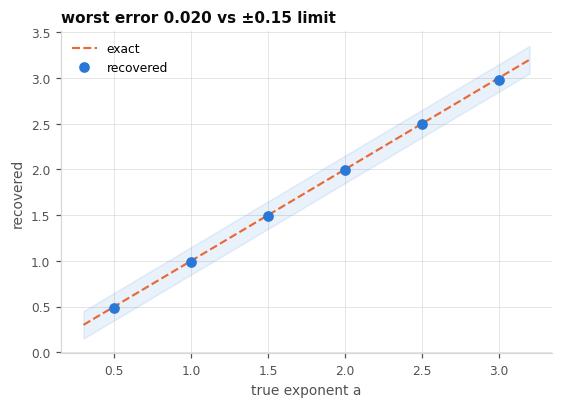

In [10]:
exponents = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
recovered = np.array(
    [
        fit_power_law(
            multitaper_psd(
                power_law_noise(
                    n_samples=int(8 * FS), sample_rate=FS, exponent=float(a), knee=1.0, seed=0
                ),
                sample_rate=FS,
            ),
            low=2.0,
            high=40.0,
        ).exponent
        for a in exponents
    ]
)

fig, ax = plt.subplots(figsize=(5.0, 3.6), constrained_layout=True)
ax.plot([0.3, 3.2], [0.3, 3.2], color=TRUTH, ls="--", lw=1.4, label="exact")
ax.fill_between([0.3, 3.2], [0.15, 3.05], [0.45, 3.35], color=BAND, alpha=0.10)
ax.plot(exponents, recovered, "o", color=ESTIMATE, ms=6, label="recovered")
ax.set_xlabel("true exponent a")
ax.set_ylabel("recovered")
ax.legend(loc="upper left")
ax.set_title(f"worst error {np.max(np.abs(recovered - exponents)):.3f} vs ±0.15 limit", loc="left")
plt.show()

## What this establishes

**Demonstrated here**

- The periodogram is inconsistent: its relative scatter is ~1 at every record length, so
  variance reduction must come from averaging, and multitaper averages across orthogonal
  tapers rather than across segments.
- $K \leq 2\cdot NW - 1$ is a count of eigenvalues near 1, not a convention — measured
  $\lambda_6 = 0.937$, $\lambda_7 = 0.699$.
- The one-sided normalisation satisfies Parseval against the taper-weighted mean square to
  machine precision, and comparing against `var(x)` instead measures sampling error.
- A multitaper spectral line is a plateau of width $2W$. The argmax error scales with $W$,
  exceeds a full bin at 4 s, and cannot be fixed with zero-padding. The power-weighted
  centroid over the same band is 26× inside the requirement.
- The peak bin and the signal power are different physical quantities.
- The slope fit must start above $2W$, for three independent reasons.

**Not established here**

- Nothing about real EEG. Every signal in this notebook is synthetic with a known answer.
- Nothing about artifacts — line noise, electrode pop and lead-off are out of scope.
- Adaptive (Thomson eigenvalue) weighting, which would improve the dynamic-range limit noted
  in the report, is not implemented.

**Next:** [`02_filter_consistency.ipynb`](02_filter_consistency.ipynb) — the recursive
estimator, and how to tell whether the uncertainty it reports is honest.